# scPoli 二级注释流程 Python版

基于一级校正结果 `cell_type_level1_corrected` 做 subset/recluster，并用 marker 得到二级注释列 `cell_type_level2`。
这个scpoli是基于校正后的embedding
该文件的输出都在：/home/lixiangyu/zr/Annotate/ANNOTATE_new/8_annotate_level2/0514_rename_level2/output_allhuman/work_0514

# import

In [1]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)

In [2]:
raw_h5ad="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_mouse_scpoli/work_0513/mouse_scpoli_concat_corrected_all.h5ad"##只有小鼠数据 原始counts + annot,现在这个文件中的cell_type_level1是ground truth
scpoli_h5ad="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_mouse_scpoli/work_0513/mouse_scpoli_concat_corrected_all_no_gene.h5ad"### all human scpoli data without gene names, but with annotation
outdir="./output_mouse/work_0514/"
counts_layer="counts"
original_celltype_col="cell_type_level1_corrected"##原始文件里的标签
os.makedirs(outdir,exist_ok=True)

In [3]:
#####读取文件 按 adata_scpoli 的细胞ID 对齐 adata_raw
adata_raw=sc.read_h5ad(raw_h5ad)
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
print(adata_raw)
print(adata_raw.obs_names)
print(adata_scpoli)
print(adata_scpoli.obs_names)

AnnData object with n_obs × n_vars = 561576 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [4]:
adata_scpoli.obs_names = adata_scpoli.obs['barcode_for_match'].values

In [5]:
adata_scpoli.obs_names

Index(['AAACCCAAGAATCGCG-1', 'AAACCCAAGACCTCCG-1', 'AAACCCAAGAGATCGC-1',
       'AAACCCAAGGTAAAGG-1', 'AAACCCACAGACGCTC-1', 'AAACCCAGTATCAGGG-1',
       'AAACCCATCCCAATAG-1', 'AAACCCATCTGCTGAA-1', 'AAACGAATCTGCGATA-1',
       'AAACGCTAGACGTCGA-1',
       ...
       'TTGTTCCAATAGTCTTGACATGAATGA', 'TTGTTCCAATAGTGACTACAACGATCT',
       'TTGTTCCAATCATCCTAACTATCATGA', 'TTGTTCCAATCATTGAGAGGTTGGACA',
       'TTGTTCCAATCGTTAGCAAACATCCAT', 'TTGTTCCAATGACAGACAAAGTTTACG',
       'TTGTTCCAATTCCATTGAAACGTGTGA', 'TTGTTCCAATTCCATTGAAATGTATCG',
       'TTGTTCCAATTCCATTGAAGCCTGGTT', 'TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', length=543503)

In [6]:
adata_raw.obs_names = adata_raw.obs['barcode_for_match'].values

In [7]:
adata_raw.obs_names

Index(['AAACCCAAGAATCGCG-1', 'AAACCCAAGACCTCCG-1', 'AAACCCAAGAGATCGC-1',
       'AAACCCAAGGTAAAGG-1', 'AAACCCACAGACGCTC-1', 'AAACCCAGTATCAGGG-1',
       'AAACCCATCCCAATAG-1', 'AAACCCATCTGCTGAA-1', 'AAACGAATCTGCGATA-1',
       'AAACGCTAGACGTCGA-1',
       ...
       'TTGTTCCAATAGTCTTGACATGAATGA', 'TTGTTCCAATAGTGACTACAACGATCT',
       'TTGTTCCAATCATCCTAACTATCATGA', 'TTGTTCCAATCATTGAGAGGTTGGACA',
       'TTGTTCCAATCGTTAGCAAACATCCAT', 'TTGTTCCAATGACAGACAAAGTTTACG',
       'TTGTTCCAATTCCATTGAAACGTGTGA', 'TTGTTCCAATTCCATTGAAATGTATCG',
       'TTGTTCCAATTCCATTGAAGCCTGGTT', 'TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', length=561576)

In [8]:
import pandas as pd

raw_ids = pd.Index(adata_raw.obs["match_id"].astype(str))
scp_ids = pd.Index(adata_scpoli.obs["match_id"].astype(str))

missing = scp_ids[~scp_ids.isin(raw_ids)]

print("raw cells:", len(raw_ids))
print("scpoli cells:", len(scp_ids))

print("raw unique match_id:", raw_ids.nunique())
print("scpoli unique match_id:", scp_ids.nunique())

print("raw duplicated match_id:", raw_ids.duplicated().sum())
print("scpoli duplicated match_id:", scp_ids.duplicated().sum())

print("scpoli IDs missing in raw:", len(missing))
print("scpoli unique IDs missing in raw:", pd.Index(missing).nunique())

if len(missing) == 0:
    print("结论：adata_scpoli 是 adata_raw 的子集。")
else:
    print("结论：adata_scpoli 不是 adata_raw 的完整子集。")
    print("前 50 个 missing ID:")
    print(pd.Index(missing).unique()[:50].tolist())

raw cells: 561576
scpoli cells: 543503
raw unique match_id: 561576
scpoli unique match_id: 543503
raw duplicated match_id: 0
scpoli duplicated match_id: 0
scpoli IDs missing in raw: 0
scpoli unique IDs missing in raw: 0
结论：adata_scpoli 是 adata_raw 的子集。


In [9]:
### 得到共同的细胞：直接按照 obs_names 对齐

adata_raw.obs_names = adata_raw.obs_names.astype(str)
adata_scpoli.obs_names = adata_scpoli.obs_names.astype(str)

## 检查 obs_names 是否唯一
print("raw duplicated obs_names:", adata_raw.obs_names.duplicated().sum())
print("scpoli duplicated obs_names:", adata_scpoli.obs_names.duplicated().sum())

if adata_raw.obs_names.duplicated().sum() > 0:
    raise ValueError("adata_raw obs_names 有重复，不能安全匹配")

if adata_scpoli.obs_names.duplicated().sum() > 0:
    raise ValueError("adata_scpoli obs_names 有重复，不能安全匹配")

## 以 scpoli 为准，从 raw 中取相同细胞
scp_ids = adata_scpoli.obs_names

missing = scp_ids[~scp_ids.isin(adata_raw.obs_names)]
print("scpoli cells:", len(scp_ids))
print("missing in raw:", len(missing))
if len(missing) > 0:
    print(missing[:50].tolist())
    raise ValueError("有 scpoli 细胞在 raw 中找不到")

## 按照 scpoli 的顺序排列 raw
adata = adata_raw[scp_ids, :].copy()
adata_com_scpoli = adata_scpoli.copy()

assert np.all(adata.obs_names == adata_com_scpoli.obs_names)

print("aligned adata:", adata)
print("aligned adata_com_scpoli:", adata_com_scpoli)

raw duplicated obs_names: 0
scpoli duplicated obs_names: 0
scpoli cells: 543503
missing in raw: 0
aligned adata: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE13

In [10]:
adata_com_scpoli.write(os.path.join(outdir, "mouse_scpoli_com_level2.h5ad"))
adata.write(os.path.join(outdir, "mouse_raw_com_level2.h5ad"))

In [11]:
##选择原始 counts 矩阵，并检查它像不像真正的原始计数
if counts_layer in adata.layers:
    adata.X=adata.layers[counts_layer].copy()
    print("use layer:",counts_layer)
else:
    print("layer not found,use adata.X:",counts_layer)
adata.layers["counts"]=adata.X.copy()
x=adata.layers["counts"]
v=x.data if sp.issparse(x) else np.ravel(x)
v=v[:min(len(v),1000000)]
print("counts min",np.min(v),"max",np.max(v),"integer-like",np.allclose(v,np.round(v)))

use layer: counts
counts min 1 max 18798 integer-like True


In [12]:
#####添加需要的obs
run_tag="prelevel2"
for c in ["leiden","cell_type_level1_corrected"]:
    if c in adata_com_scpoli.obs:
        adata.obs[c]=adata_com_scpoli.obs[c].values
        print("+obs",c)
X=adata_com_scpoli.X.toarray() if sp.issparse(adata_com_scpoli.X) else np.asarray(adata_com_scpoli.X)
adata.obsm["X_scPoli"]=X
if "X_umap" in adata_com_scpoli.obsm:
    adata.obsm["X_umap"]=np.asarray(adata_com_scpoli.obsm["X_umap"])
print("X_scPoli",adata.obsm["X_scPoli"].shape)
print("X_umap",adata.obsm["X_umap"].shape if "X_umap" in adata.obsm else None)
adata.write(os.path.join(outdir,f"mouse_raw_counts_scpoli_{run_tag}.h5ad"))

+obs leiden
+obs cell_type_level1_corrected
X_scPoli (543503, 10)
X_umap (543503, 2)


In [ ]:
# ##合并后先画一张全体细胞的 UMAP，检查 cell_type_pred 是否正常
# # if "X_umap" in adata.obsm and "cell_type_level1_corrected" in adata.obs:
# #     sc.pl.umap(adata,color="cell_type_level1_corrected",legend_loc="on data",frameon=False,size=1,show=False)
# #     plt.savefig(os.path.join(outdir,"umap_cell_type_corrected_full.pdf"),bbox_inches="tight")
# #     plt.close()
# color_palette_level1 = {
#     'T cell': '#3182bd',
#     'Macrophage': '#8c564b',
#     'Erythrocyte/Erythroid': '#ff7f0e',
#     'Mast cell': '#d62728',
#     'Natural killer cell': '#98df8a',
#     'Pericyte': '#f7b6d2',
#     'Smooth muscle cell': '#7b4173',
#     'Fibroblast': '#e377c2',
#     'B cell': '#2ca02c',
#     'Dendritic cell': '#807dba',
#     'Endothelial cell': '#fdae6b',
#     'Monocyte': '#c7c7c7',
#     'Neutrophil': '#17becf',
#     'Basophil': '#ac8d62',
#     'Reference': 'white'
# }

# if "X_umap" in adata.obsm and "cell_type_level1_corrected" in adata.obs:
#     # 只保留当前数据中实际存在的类别，避免 palette 和类别不匹配
#     present_categories = [
#         ct for ct in color_palette_level1
#         if ct in adata.obs["cell_type_level1_corrected"].astype(str).unique()
#     ]

#     adata.obs["cell_type_level1_corrected"] = pd.Categorical(
#         adata.obs["cell_type_level1_corrected"].astype(str),
#         categories=present_categories,
#         ordered=True
#     )

#     sc.pl.umap(
#         adata,
#         color="cell_type_pred",
#         palette=color_palette_level1,
#         legend_loc="on data",
#         frameon=False,
#         size=1,
#         show=False
#     )

#     plt.savefig(
#         os.path.join(outdir, "umap_cell_type_corrected_full.pdf"),
#         bbox_inches="tight"
#     )
#     plt.close()
# adata

In [13]:
adata.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
Smooth muscle cell       128121
Fibroblast               123479
Macrophage                96966
T cell                    77043
B cell                    28064
Monocyte                  26707
Endothelial cell          26566
Neutrophil                13235
Erythrocyte/Erythroid      7677
Dendritic cell             7386
Natural killer cell        5676
Pericyte                   1293
Basophil                   1106
Mast cell                   184
Name: count, dtype: int64

# mac

In [14]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/mac/"

In [15]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [16]:
mac = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Macrophage"],
    outdir=outdir,
    prefix="mac_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Macrophage']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mac/umap_mac_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mac/umap_mac_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mac/umap_mac_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     4244
1     3882
2     3663
3     3519
4     3376
5     3369
6     3338
7     3244
8     3219
9     3174
10    3127
11    3068
12    2941
13    2779
14    2728
15    2688
16    2680
17    2634
18    2620
19    2580
20    2567
21    2560
22    2487
23    2399
24    2339
25    2215
26    1967
27    1813
28    1755
29    1663
30    1545
31    1453
32    1378
33    1136
34     975
35     914
36     890
37     847
38     800
39     775
40     679
41     474
42     462
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/mac/mac_level2_scPoli_recluster_umap.h5ad


In [3]:
work = sc.read_h5ad(os.path.join(outdir, "mac_level2_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 104714 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_level1_corrected_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [4]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "Inflammatory macrophage": ['S100A8', 'IL1B', 'S100A9','IRF7', 'IFITM3', 'ISG15', 'IFIT2'],
    "Foamy macrophage": ['TREM2', 'MARCO', 'FABP4','FABP5', 'CD36'],
    "Homeostatic/Resident macrophage": ['LYVE1', 'MRC1', 'F13A1', 'SEPP1', 'IGF1', 'GAS6', 'MERTK', 'STAB1', 'C1QA', 'C1QB', 'C1QC', 'FOLR2'],
    "Proliferative macrophage": ['MKI67', 'TOP2A', 'PCNA', 'BIRC5', 'MCM2','MCM4','MCM5', 'TK1'],
    "Matrix-remodeling/SMC-like macrophage": ['AEBP1', 'COL1A1', 'COL1A2', 'THBS2', 'MMP3', 'S100A16', 'TNC', 'PDGFRB'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
Inflammatory macrophage ['S100A8', 'IL1B', 'S100A9', 'IRF7', 'IFITM3', 'ISG15', 'IFIT2']
Foamy macrophage ['TREM2', 'MARCO', 'FABP4', 'FABP5', 'CD36']
Homeostatic/Resident macrophage ['LYVE1', 'MRC1', 'F13A1', 'IGF1', 'GAS6', 'MERTK', 'STAB1', 'C1QA', 'C1QB', 'C1QC', 'FOLR2']
Proliferative macrophage ['MKI67', 'TOP2A', 'PCNA', 'BIRC5', 'MCM2', 'MCM4', 'MCM5', 'TK1']
Matrix-remodeling/SMC-like macrophage ['AEBP1', 'COL1A1', 'COL1A2', 'THBS2', 'MMP3', 'S100A16', 'TNC', 'PDGFRB']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [5]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "mac_mono_neu_cluster_level2_marker_summary.csv"))


                                  major_marker  major_marker_frac  n_cells                    cluster_label_clean
cluster                                                                                                          
0              Homeostatic/Resident macrophage           0.916620     3610        Homeostatic/Resident macrophage
1                             Foamy macrophage           0.790495     3556                       Foamy macrophage
2              Homeostatic/Resident macrophage           0.683314     3524        Homeostatic/Resident macrophage
3                      Inflammatory macrophage           0.633217     3149                Inflammatory macrophage
4                      Inflammatory macrophage           0.752123     3062                Inflammatory macrophage
5                             Foamy macrophage           0.360634     3028                       Foamy macrophage
6              Homeostatic/Resident macrophage           0.952527     2928        Homeos

In [20]:
corrected_annotation = {
    "0": "Neutrophil",
    "1": "Monocyte",
    "2": "Monocyte",
    "3": "Monocyte",
    "4": "Macrophage",
    "5": "Macrophage",
    "6": "Macrophage",
    "7": "Macrophage",
    "8": "Macrophage",
    "9": "Neutrophil",
    "10": "Macrophage",
    "11": "Neutrophil",
    "12": "Monocyte",
    "13": "Macrophage",
    "14": "Macrophage",
    "15": "Macrophage",
    "16": "Macrophage",
    "17": "Macrophage",
    "18": "Macrophage",
    "19": "Macrophage",
    "20": "Macrophage",
    "21": "Macrophage",
    "22": "Neutrophil",
    "23": "Macrophage",
    "24": "Macrophage",
    "25": "Monocyte",##inflammatory monocyte
    "26": "Macrophage",
    "27": "Monocyte",
    "28": "Macrophage",
    "29": "Macrophage",
    "30": "Monocyte",
    "31": "Macrophage",
    "32": "Macrophage",
    "33": "Macrophage",
    "34": "Macrophage",
    "35": "Macrophage",
    "36": "Neutrophil",
    "37": "Macrophage",
    "38": "Neutrophil",
    "39": "Macrophage",
    "40": "Macrophage",
    "41": "Neutrophil",
    "42": "Macrophage",
    "43": "Macrophage",
    "44": "Neutrophil"
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2_marker"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
Macrophage    55921
Monocyte      16642
Neutrophil    13738
Name: count, dtype: int64


In [22]:
work.write_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))

In [ ]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2_marker",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cell_type_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# smc

In [17]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/smc"

In [18]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [19]:
smc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Smooth muscle cell"],
    outdir=outdir,
    prefix="smc_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Smooth muscle cell']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GS

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/smc/umap_smc_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/smc/umap_smc_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/smc/umap_smc_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     4766
1     4488
2     4225
3     4156
4     4029
5     3952
6     3680
7     3646
8     3613
9     3438
10    3420
11    3343
12    3304
13    3216
14    3160
15    3155
16    3081
17    3065
18    3064
19    3054
20    3042
21    3017
22    3007
23    2954
24    2869
25    2857
26    2730
27    2723
28    2684
29    2639
30    2378
31    2302
32    2283
33    2267
34    2127
35    1932
36    1920
37    1919
38    1825
39    1785
40    1513
41    1502
42    1208
43     957
44     862
45     639
46     325
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/smc/smc_level2_scPoli_recluster_umap.h5ad


In [ ]:
work = sc.read_h5ad(os.path.join(outdir, "smc_level2_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 92250 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [ ]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "Smooth muscle cell": ['MYH11','MYL9','TPM2','CALD1','TAGLN','APOE','APOC1','AGT','NOTCH3','PDGFRB','MFAP4'],#'LUM','TNFRSF11B','ACTA2',
    "Fibromyocyte": ['FN1','LUM','TNFRSF11B','ACTA2','TCF21']
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [28]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "smc_fibro_cluster_level2_marker_summary.csv"))


                 major_pred  major_pred_frac        major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                         
0        Smooth muscle cell         1.000000  Smooth muscle cell           0.935529     4281  Smooth muscle cell
1                Fibroblast         1.000000          Fibroblast           0.999749     3991          Fibroblast
2        Smooth muscle cell         0.993863  Smooth muscle cell           0.601953     3585  Smooth muscle cell
3                Fibroblast         1.000000          Fibroblast           0.988640     3521          Fibroblast
4                Fibroblast         0.835270          Fibroblast           0.379140     3442           Uncertain
5        Smooth muscle cell         1.000000  Smooth muscle cell           0.965711     3383  Smooth muscle cell
6        Smooth muscle cell         1.000000  Smooth muscle cell           0.756674     3259  Sm

In [29]:
corrected_annotation = {
    "0": "Smooth muscle cell",
    "1": "Fibroblast",
    "2": "Smooth muscle cell",
    "3": "Fibroblast",
    "4": "Erythrocyte/Erythroid",
    "5": "Smooth muscle cell",
    "6": "Smooth muscle cell",
    "7": "Fibroblast",
    "8": "Smooth muscle cell",
    "9": "Fibroblast",
    "10": "Smooth muscle cell",
    "11": "Fibroblast",
    "12": "Fibroblast",
    "13": "Smooth muscle cell",
    "14": "Smooth muscle cell",
    "15": "Fibroblast",
    "16": "Smooth muscle cell",
    "17": "Fibroblast",
    "18": "Smooth muscle cell",
    "19": "Fibroblast",
    "20": "Smooth muscle cell",
    "21": "Fibroblast",
    "22": "Fibroblast",
    "23": "Fibroblast",
    "24": "Fibroblast",
    "25": "Fibroblast",
    "26": "Fibroblast",
    "27": "Smooth muscle cell",
    "28": "Fibroblast",
    "29": "Fibroblast",
    "30": "Fibroblast",
    "31": "Smooth muscle cell",
    "32": "Fibroblast",
    "33": "Fibroblast",
    "34": "Smooth muscle cell",
    "35": "Smooth muscle cell",
    "36": "Fibroblast",
    "37": "Fibroblast",
    "38": "Smooth muscle cell",
    "39": "Smooth muscle cell",
    "40": "Smooth muscle cell",
    "41": "Fibroblast"
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2_marker"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
Fibroblast               48012
Smooth muscle cell       40796
Erythrocyte/Erythroid     3442
Name: count, dtype: int64


In [30]:
work.write_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap_corrected.h5ad"))

In [31]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2_marker",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_smc_fib_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_smc_fib_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_smc_fib_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# T cell

In [20]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/tc"

In [21]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [22]:
tc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["T cell"],
    outdir=outdir,
    prefix="tc_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['T cell']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UM

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/tc/umap_tc_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/tc/umap_tc_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/tc/umap_tc_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     3526
1     3122
2     3106
3     3014
4     3002
5     2910
6     2695
7     2684
8     2653
9     2541
10    2409
11    2400
12    2281
13    2264
14    2189
15    2085
16    2082
17    1905
18    1894
19    1892
20    1844
21    1757
22    1757
23    1716
24    1700
25    1695
26    1646
27    1633
28    1495
29    1472
30    1429
31    1395
32    1380
33    1335
34    1037
35     976
36     845
37     808
38     469
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/tc/tc_level2_scPoli_recluster_umap.h5ad


In [ ]:
work = sc.read_h5ad(os.path.join(outdir, "tc_level2_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 183446 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [ ]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "CD8 T cell":['CCL4L2', 'CRTAM', 'GZMK', 'CCL4', 'CD8A', 'GZMH'], 
    "CD4 T cell":['IL7R', 'ANXA1', 'FTH1', 'CD4', 'BATF', 'TNFRSF4', 'TNFRSF18']
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [35]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "tc_cluster_level2_marker_summary.csv"))


        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           T cell              1.0       T cell           0.586424     7145              T cell
1           T cell              1.0       T cell           0.678833     6274              T cell
2           T cell              1.0   Neutrophil           0.582163     6268           Uncertain
3           T cell              1.0       T cell           0.730503     6078              T cell
4           T cell              1.0       T cell           0.822362     5545              T cell
5           T cell              1.0   Neutrophil           0.535537     5445           Uncertain
6           T cell              1.0       T cell           0.762434     5308              T cell
7           T cell              1.0   Neutrophil           0.478195     5297           Uncertain
8           T cell            

In [37]:
corrected_annotation = {
    "2" : "T cell",
    "5" : "T cell",
    "7" : "T cell",
    "43" : "T cell",
    "44" : "T cell",
    "46" : "T cell",
    "47": "Undefine"
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2_marker"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
T cell      183300
Undefine       146
Name: count, dtype: int64


In [38]:
work.write_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap_corrected.h5ad"))

In [39]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2_marker",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_tc_cell_type_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_tc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_tc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_tc_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# ECs

In [23]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/ec"

In [24]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [25]:
ec = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Endothelial cell"],
    outdir=outdir,
    prefix="ec_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Endothelial cell']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE1

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/ec/umap_ec_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/ec/umap_ec_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/ec/umap_ec_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1230
1     1169
2     1119
3     1099
4     1099
5     1097
6     1052
7     1040
8     1015
9     1011
10     974
11     889
12     886
13     884
14     876
15     807
16     806
17     782
18     769
19     698
20     690
21     662
22     647
23     624
24     590
25     564
26     548
27     546
28     535
29     504
30     427
31     420
32     273
33     234
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/ec/ec_level2_scPoli_recluster_umap.h5ad


In [ ]:
work = sc.read_h5ad(os.path.join(outdir, "ec_level2_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 30615 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [46]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    # "cDC2": [ "CD1E", "CD1D"],
    # "cDC1": ["CLEC9A", "XCR1", "BATF3", "IRF8", "CADM1"],
    # "pDC": ["IL3RA", "CLEC4C", "LILRA4", "GZMB", "TCF4", "IRF7", "SPIB"],
    # "mature_DC": ["CCR7", "LAMP3", "FSCN1", "CCL19", "CCL17", "CCL22"],
    # "pan_APC_DC": [ "HLA-DPA1", "HLA-DPB1", "CD74", "ITGAX"],

    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [47]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "ec_cluster_level2_marker_summary.csv"))


               major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                     
0        Endothelial cell              1.0    Dendritic cell           0.610541     1461           Uncertain
1        Endothelial cell              1.0  Endothelial cell           0.580330     1332    Endothelial cell
2        Endothelial cell              1.0  Endothelial cell           0.976228     1262    Endothelial cell
3        Endothelial cell              1.0  Endothelial cell           0.968986     1193    Endothelial cell
4        Endothelial cell              1.0    Dendritic cell           0.740157     1143           Uncertain
5        Endothelial cell              1.0  Endothelial cell           0.913315     1119    Endothelial cell
6        Endothelial cell              1.0    Dendritic cell           0.494624     1116           Uncertain
7        Endothelia

In [48]:
corrected_annotation = {
    "0": "Endothelial cell",
    "1": "Endothelial cell",
    "2": "Endothelial cell",
    "3": "Endothelial cell",
    "4": "Endothelial cell",
    "5": "Endothelial cell",
    "6": "Endothelial cell",
    "7": "Endothelial cell",
    "8": "Endothelial cell",
    "9": "Endothelial cell",
    "10": "Endothelial cell",
    "11": "Endothelial cell",
    "12": "Endothelial cell",
    "13": "Endothelial cell",
    "14": "Endothelial cell",
    "15": "Endothelial cell",
    "16": "Endothelial cell",
    "17": "Endothelial cell",
    "18": "Endothelial cell",
    "19": "Endothelial cell",
    "20": "Endothelial cell",
    "21": "Endothelial cell",
    "22": "Endothelial cell",
    "23": "Endothelial cell",
    "24": "Endothelial cell",
    "25": "Endothelial cell",
    "26": "Endothelial cell",
    "27": "Endothelial cell",
    "28": "Endothelial cell",
    "29": "Endothelial cell",
    "30": "Endothelial cell",
    "31": "Endothelial cell",
    "32": "Endothelial cell",
    "33": "Endothelial cell",
    "34": "Monocyte"
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2_marker"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
Endothelial cell    30383
Monocyte              232
Name: count, dtype: int64


In [49]:
work.write_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap_corrected.h5ad"))

In [50]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2_marker",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_ec_cell_type_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_ec_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_ec_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_ec_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# dc

In [26]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/dc"

In [27]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [28]:
dc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Dendritic cell"],
    outdir=outdir,
    prefix="dc_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Dendritic cell']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/dc/umap_dc_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/dc/umap_dc_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/dc/umap_dc_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     431
1     418
2     392
3     376
4     350
5     348
6     344
7     330
8     292
9     281
10    272
11    262
12    253
13    245
14    243
15    241
16    241
17    233
18    223
19    203
20    197
21    194
22    182
23    173
24    163
25    160
26    160
27    126
28     53
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/dc/dc_level2_scPoli_recluster_umap.h5ad


In [ ]:
work = sc.read_h5ad(os.path.join(outdir, "dc_level2_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 51294 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [ ]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "cDC1": ["CLEC9A", "IRF8", "SNX3"],
    "cDC2": ["CD1C", "CLEC10A", "FCER1A"],
    "Plasmacytoid dendritic cell": ["IRF7", "TLR7", "TLR9", "NRP1", "CLEC4C", "SCAMP5", "GZMB", "TCF4"]
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_dc_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_dc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [ ]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "dc_cluster_level2_marker_summary.csv"))


                  major_pred  major_pred_frac         major_marker  major_marker_frac  n_cells  cluster_label_clean
cluster                                                                                                            
0        Natural killer cell              1.0               T cell           0.475394     2032            Uncertain
1        Natural killer cell              1.0               T cell           0.554571     1805            Uncertain
2        Natural killer cell              1.0  Natural killer cell           0.611940     1742  Natural killer cell
3        Natural killer cell              1.0  Natural killer cell           0.995343     1718  Natural killer cell
4        Natural killer cell              1.0  Natural killer cell           0.881797     1692  Natural killer cell
5        Natural killer cell              1.0  Natural killer cell           0.999395     1654  Natural killer cell
6        Natural killer cell              1.0  Natural killer cell      

In [ ]:
corrected_annotation = {
    "0": "T cell",
    "1": "T cell",
    "2": "T cell",
    "3": "Natural killer cell",
    "4": "Natural killer cell",
    "5": "Natural killer cell",
    "6": "Natural killer cell",
    "7": "T cell",
    "8": "Natural killer cell",
    "9": "Natural killer cell",
    "10": "Natural killer cell",
    "11": "Natural killer cell",
    "12": "T cell",
    "13": "Natural killer cell",
    "14": "T cell",
    "15": "T cell",
    "16": "Natural killer cell",
    "17": "T cell",
    "18": "Natural killer cell",
    "19": "Natural killer cell",
    "20": "Natural killer cell",
    "21": "T cell",
    "22": "T cell",
    "23": "Natural killer cell",
    "24": "Natural killer cell",
    "25": "Natural killer cell",
    "26": "Natural killer cell",
    "27": "Natural killer cell",
    "28": "Natural killer cell",
    "29": "T cell",
    "30": "Natural killer cell",
    "31": "Natural killer cell",
    "32": "Natural killer cell",
    "33": "Natural killer cell",
    "34": "T cell",
    "35": "Natural killer cell",
    "36": "Natural killer cell",
    "37": "Natural killer cell",
    "38": "Natural killer cell",
    "39": "T cell",
    "40": "Natural killer cell",
    "41": "Natural killer cell",
    "42": "Undefine",
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
Natural killer cell    33466
T cell                 17747
Undefine                  81
Name: count, dtype: int64


In [ ]:
work.write_h5ad(os.path.join(outdir, "dc_scPoli_recluster_umap_level2.h5ad"))

In [ ]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_dc_cell_type_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_nk_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_dc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_dc_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# B cells

In [29]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/bc"

In [30]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [31]:
bc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["B cell"],
    outdir=outdir,
    prefix="bc_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['B cell']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UM

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/bc/umap_bc_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/bc/umap_bc_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/bc/umap_bc_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1076
1      944
2      926
3      923
4      919
5      910
6      890
7      886
8      876
9      870
10     868
11     850
12     843
13     802
14     782
15     775
16     763
17     761
18     757
19     706
20     672
21     658
22     639
23     634
24     628
25     598
26     591
27     585
28     584
29     572
30     571
31     554
32     530
33     523
34     438
35     414
36     405
37     394
38     367
39     327
40     148
41      63
42      42
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/bc/bc_level2_scPoli_recluster_umap.h5ad


In [60]:
work = sc.read_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 56046 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [63]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    # "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Dendritic cell": [
    "CD1C", "CLEC10A", "FCER1A",
    "CLEC9A", "XCR1", "BATF3",
    "CLEC4C", "LILRA4", "TCF4",
    "LAMP3", "CCR7", "FSCN1"
],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_level1_corrected.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CD1C', 'CLEC10A', 'FCER1A', 'CLEC9A', 'XCR1', 'BATF3', 'CLEC4C', 'LILRA4', 'TCF4', 'LAMP3', 'CCR7', 'FSCN1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [64]:
# cluster-level 二级注释：不用预测标签多数派，只看每个 scPoli cluster 内的 marker_top 多数派
if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
    n_cells = marker_tab.sum(axis=1)
else:
    clusters = work.obs[cluster_key].astype(str).value_counts().sort_index().index
    cluster_major_marker = pd.Series("Unknown", index=clusters)
    cluster_major_marker_frac = pd.Series(np.nan, index=clusters)
    n_cells = work.obs[cluster_key].astype(str).value_counts().reindex(clusters).fillna(0).astype(int)

cluster_summary = pd.DataFrame({
    "cluster": cluster_major_marker.index.astype(str),
    "major_marker": cluster_major_marker.values,
    "major_marker_frac": cluster_major_marker_frac.reindex(cluster_major_marker.index).values,
    "n_cells": n_cells.reindex(cluster_major_marker.index).values,
}).set_index("cluster")

# marker-only 结果：不再使用预测标签多数派
cluster_summary["cluster_label_clean"] = cluster_summary["major_marker"].astype(str)
cluster_summary.loc[cluster_summary["cluster_label_clean"].eq("Unknown"), "cluster_label_clean"] = "Uncertain"

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "bc_cluster_level2_marker_summary.csv"))


        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           B cell              1.0       B cell           0.912955     2447              B cell
1           B cell              1.0       B cell           0.709603     2166              B cell
2           B cell              1.0       B cell           0.922255     2058              B cell
3           B cell              1.0       B cell           0.992126     2032              B cell
4           B cell              1.0       B cell           0.985174     1956              B cell
5           B cell              1.0       B cell           0.889861     1943              B cell
6           B cell              1.0       B cell           0.888286     1844              B cell
7           B cell              1.0       B cell           0.932930     1819              B cell
8           B cell            

In [69]:
corrected_annotation = {
    "34": "B cell",
    "36": "B cell",
    "41": "Undefine",
    "43": "Undefine",
}
# marker-only 二级注释结果：不再写回/覆盖一级列 cell_type_level1_corrected
level2_col = "cell_type_level2_marker"
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs[level2_col] = work.obs[cluster_key].astype(str).map(cluster_clean_map).fillna("Unknown")

# 如需人工覆盖 marker-only 结果，再取消下面几行注释。
# manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
# manual_mask = manual_map.notna()
# work.obs.loc[manual_mask, level2_col] = manual_map.loc[manual_mask]

print(work.obs[level2_col].value_counts())

cell_type_level1_corrected
B cell      55317
Undefine      729
Name: count, dtype: int64


In [70]:
work.write_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap_corrected.h5ad"))

In [71]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level2_marker",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_bc_cell_type_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_bc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_bc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level2_marker",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_bc_by_level2_marker.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# mono

In [32]:
label_col = "cell_type_level1_corrected"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/work_0514/mono/"

In [33]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_level1_corrected", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and marker-based level2 annotation; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [34]:
mono = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Monocyte"],
    outdir=outdir,
    prefix="mono_level2",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Monocyte']
Original object: AnnData object with n_obs × n_vars = 543503 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mono/umap_mono_level2_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mono/umap_mono_level2_cell_type_level1_corrected.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/work_0514/mono/umap_mono_level2_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1391
1     1372
2     1352
3     1244
4     1059
5     1044
6     1003
7      999
8      961
9      932
10     892
11     864
12     863
13     860
14     853
15     845
16     839
17     819
18     785
19     779
20     779
21     775
22     772
23     673
24     555
25     410
26     388
27     387
28     383
29     369
30     342
31     278
32     264
33     243
34     196
35     137
Name: count, dtype: int64
Saved to: ./output_mouse/work_0514/mono/mono_level2_scPoli_recluster_umap.h5ad


In [1]:
######还有mast cell,先不做

# 合并

In [ ]:
outdir="./output_mouse/work_0514/"

In [ ]:
adata = sc.read_h5ad("./output_mouse/work_0514/scPoli_concat_corrected_all.h5ad")
adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [6]:
adata.obs["cell_type_level1"].value_counts()


cell_type_level1
T cell                   337765
Macrophage               104489
B cell                    90335
Fibroblast                89137
Neutrophil                82791
Smooth muscle cell        74516
Natural killer cell       71295
Endothelial cell          65349
Dendritic cell            34542
Monocyte                  32888
Pericyte                  18985
Mast cell                  6959
Basophil                   6281
Erythrocyte/Erythroid      3442
Name: count, dtype: int64

In [7]:
adata_bc = sc.read_h5ad(os.path.join(outdir, "bc/bc_scPoli_recluster_umap_corrected.h5ad"))
adata_nk = sc.read_h5ad(os.path.join(outdir, "nk/nk_scPoli_recluster_umap_corrected.h5ad"))
adata_mac_mono_neu = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu/mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))
adata_smc_fibro = sc.read_h5ad(os.path.join(outdir, "smc_fibro/smc_fibro_scPoli_recluster_umap_corrected.h5ad"))
adata_tc = sc.read_h5ad(os.path.join(outdir, "tc/tc_scPoli_recluster_umap_corrected.h5ad"))
adata_ec = sc.read_h5ad(os.path.join(outdir, "ec/ec_scPoli_recluster_umap_corrected.h5ad"))

In [8]:
adata_list = [adata_bc, adata_nk,adata_mac_mono_neu,adata_smc_fibro,adata_ec,adata_ec]

In [9]:
adata_concat = anndata.concat(adata_list, join='outer', fill_value=0.0)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 347121 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [11]:
adata_concat = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 347121 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [12]:
adata_concat.obs_names

CategoricalIndex(['GSE143921_2__CTCCAGCCTTC', 'GSE143921_6__AACCTTCTTAC',
                  'GSE143921_6__AAGACTCATAT.1', 'GSE143921_6__CCGGTCCAGAG.1',
                  'GSE143921_6__GAACGAGTACT.1', 'GSE143921_6__GGTTGGTCCGT.2',
                  'GSE143921_4__GTATGGCGGCG.1',
                  'GSE155468_1__AAGGTAATCATCACAG',
                  'GSE155468_1__AATGGAAGTTTGGAGG',
                  'GSE155468_1__ACCCTCAAGTGTACAA',
                  ...
                  'GSE196943_10__ACGTAACCAGCTTTCC_J_plaque',
                  'GSE196943_10__CGAAGTTAGGGACAGG_J_plaque',
                  'GSE196943_10__CTACATTTCGAGAAGC_J_plaque',
                  'GSE196943_10__TTACGTTCAGCGACCT_J_plaque',
                  'GSE196943_10__TTAGGCAGTACGTTCA_J_plaque',
                  'GSE196943_10__TTTACCACAGCTTCCT_J_plaque',
                  'GSE196943_5__TCATTGTAGAATCGTA_E_plaque',
                  'GSE196943_12__CCACCATAGGTGTGAC_L_plaque',
                  'GSE196943_12__TTCATGTAGAGCAGAA_L_plaque',

In [13]:
# Extract barcodes and cell_type_level2_marker values
barcodes = adata_concat.obs_names
cell_types_level2 = adata_concat.obs["cell_type_level2_marker"]

# Create the mapping
mapping = dict(zip(barcodes, cell_types_level2))

In [14]:
adata.obs_names

Index(['1_JD__AAACCCAAGAGGTTAT-1', '1_JD__AAACCCAAGCAACAAT-1',
       '1_JD__AAACCCAAGGAGTCTG-1', '1_JD__AAACCCACAACTCATG-1',
       '1_JD__AAACCCACAGCTCTGG-1', '1_JD__AAACCCAGTCAAGGCA-1',
       '1_JD__AAACCCAGTCAATCTG-1', '1_JD__AAACCCAGTCACCCTT-1',
       '1_JD__AAACCCAGTGCATTAC-1', '1_JD__AAACCCAGTGCGGCTT-1',
       ...
       'GSE196943_8__ATAACGCAGTACGCCC_H_plaque',
       'GSE196943_8__CACATAGGTGTCTGAT_H_plaque',
       'GSE196943_8__CCATTCGAGTAGCCGA_H_plaque',
       'GSE196943_8__GAATAAGAGAAAGTGG_H_plaque',
       'GSE196943_8__GACCAATCATGGTAGG_H_plaque',
       'GSE196943_8__GACCTGGGTCTTCAAG_H_plaque',
       'GSE196943_8__TGGGCGTTCTTCTGGC_H_plaque',
       'GSE196943_8__GAGCAGATCAGAGGTG_H_plaque',
       'GSE196943_8__GAGTCCGGTTCTGGTA_H_plaque',
       'GSE196943_8__TCATTTGAGTTGTCGT_H_plaque'],
      dtype='object', name='match_id', length=1018774)

In [15]:
# init new column
adata.obs["cell_type_level2_marker"] = "no map"

In [16]:
### more fast
if "cell_type_level2_marker" not in adata.obs.columns:
    adata.obs["cell_type_level2_marker"] = pd.NA

mapped = adata.obs.index.to_series().map(mapping)
mask = mapped.notna()
adata.obs.loc[mask, "cell_type_level2_marker"] = mapped[mask].to_numpy()

In [17]:
adata.obs["cell_type_level2_marker"].value_counts()

cell_type_level1_corrected
no map                   702268
Macrophage                55921
B cell                    55317
Fibroblast                48012
Smooth muscle cell        40796
Natural killer cell       33466
Endothelial cell          30383
T cell                    17747
Monocyte                  16874
Neutrophil                13738
Erythrocyte/Erythroid      3442
Undefine                    810
Name: count, dtype: int64

In [18]:
adata = adata[adata.obs['cell_type_level2_marker'] != 'Undefine'].copy()
adata

AnnData object with n_obs × n_vars = 1017964 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [19]:
mask = adata.obs["cell_type_level2_marker"] == "no map"
adata.obs.loc[mask, "cell_type_level2_marker"] = "Unknown"

In [20]:
adata.obs["cell_type_level2_marker"].value_counts()

cell_type_level1_corrected
T cell                   355512
Macrophage               104714
B cell                    89606
Fibroblast                87730
Neutrophil                82372
Smooth muscle cell        72481
Endothelial cell          65117
Natural killer cell       53467
Dendritic cell            34542
Monocyte                  33314
Pericyte                  18985
Mast cell                  6959
Erythrocyte/Erythroid      6884
Basophil                   6281
Name: count, dtype: int64

In [21]:
adata.write(os.path.join(outdir,"scPoli_concat_level2_marker_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1017964 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

# 验证

In [ ]:
adata = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_level2_marker_all.h5ad"))
adata

In [23]:
adata.obs_names = adata.obs['barcode_for_match']
adata.obs_names

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:924: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1', 'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1', 'AAACCCACAGCTCTGG-1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")


CategoricalIndex(['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1',
                  'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1',
                  'AAACCCACAGCTCTGG-1', 'AAACCCAGTCAAGGCA-1',
                  'AAACCCAGTCAATCTG-1', 'AAACCCAGTCACCCTT-1',
                  'AAACCCAGTGCATTAC-1', 'AAACCCAGTGCGGCTT-1',
                  ...
                  'ATAACGCAGTACGCCC_H_plaque', 'CACATAGGTGTCTGAT_H_plaque',
                  'CCATTCGAGTAGCCGA_H_plaque', 'GAATAAGAGAAAGTGG_H_plaque',
                  'GACCAATCATGGTAGG_H_plaque', 'GACCTGGGTCTTCAAG_H_plaque',
                  'TGGGCGTTCTTCTGGC_H_plaque', 'GAGCAGATCAGAGGTG_H_plaque',
                  'GAGTCCGGTTCTGGTA_H_plaque', 'TCATTTGAGTTGTCGT_H_plaque'],
                 categories=['AAACATCGAAACATCGAACTCACC', 'AAACATCGAAACATCGCCTAATCC', 'AAACATCGAACAACCAGAGCTGAA', 'AAACATCGAACCGAGATTCACGCA', ..., 'TTTGTTGTCTTGGTCC-1-1', 'TTTGTTGTCTTGTGCC-1', 'TTTGTTGTCTTTACAC', 'TTTGTTGTCTTTGATC-1'], ordered=False, dtype='category', name='barcode_for_m

In [24]:
adata_ref = sc.read_h5ad(
    "/home/lixiangyu/zr/Annotate/label/label_4/Atlas_AS_NC.h5ad")
adata_ref.obs

,donor_id,dataset,cell_type_level1,cell_type_level2,origin,sorting,disease_ontology_term_id,tissue_type,tissue_ontology_term_id,suspension_type,...,is_primary_data,size_factors,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCCACAATCACGT-1_4,4_Bashore,Bashore,Fibroblast,Fibroblast,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.352056,fibroblast,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,?4>WB;!91R
AAACCCACAGGAGGAG-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,1.735624,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,5k(8`xeS`6
AAACCCATCGACTCCT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.663582,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,BB@ZxJ+(hO
AAACGAAAGTGGTGAC-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,2.320199,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,$yqWk{IXbA
AAACGAACACTCCACT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,6.565568,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,8%^wjg_>7*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1,2_Jaiswal,Jaiswal,T cell,CD8 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.609612,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,3C*7VY5HZk
Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1,2_Jaiswal,Jaiswal,T cell,CD4 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.659197,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,me&AN5JDe?
Fresh_DTAN_4047_TTTGTCATCAACACAC-1,2_Jaiswal,Jaiswal,NK cell,NK cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.654566,natural killer cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,^8tj9V=52}
Fresh_DTAN_4047_TTTGTCATCATAACCG-1,2_Jaiswal,Jaiswal,B cell,B cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.463384,B cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,;Ty<N{5tO=


In [25]:
adata_ref.obs_names = adata_ref.obs_names.str.replace(r'_\d+$', '', regex=True)
adata_ref.obs_names

Index(['AAACCCACAATCACGT-1', 'AAACCCACAGGAGGAG-1', 'AAACCCATCGACTCCT-1',
       'AAACGAAAGTGGTGAC-1', 'AAACGAACACTCCACT-1', 'AAACGAAGTATCGATC-1',
       'AAACGAATCGTAGTCA-1', 'AAACGCTCAAGCTGCC-1', 'AAACGCTTCGCAGTGC-1',
       'AAAGAACAGGAACGAA-1',
       ...
       'Fresh_DTAN_4047_TTTGGTTCAGGCAGTA-1',
       'Fresh_DTAN_4047_TTTGGTTCATGGTTGT-1',
       'Fresh_DTAN_4047_TTTGGTTGTCTTCAAG-1',
       'Fresh_DTAN_4047_TTTGGTTTCTAACTTC-1',
       'Fresh_DTAN_4047_TTTGGTTTCTATGTGG-1',
       'Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1',
       'Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1',
       'Fresh_DTAN_4047_TTTGTCATCAACACAC-1',
       'Fresh_DTAN_4047_TTTGTCATCATAACCG-1',
       'Fresh_DTAN_4047_TTTGTCATCGGAAATA-1'],
      dtype='object', length=259116)

In [30]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2/scPoli_concat_level2_marker_all.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1_corrected"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

: 

当前 AnnData 中共有 547398 个细胞
去除指定细胞类型后共有 528232 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 203166 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.6542
Weighted precision: 0.7409
Weighted recall: 0.6542

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


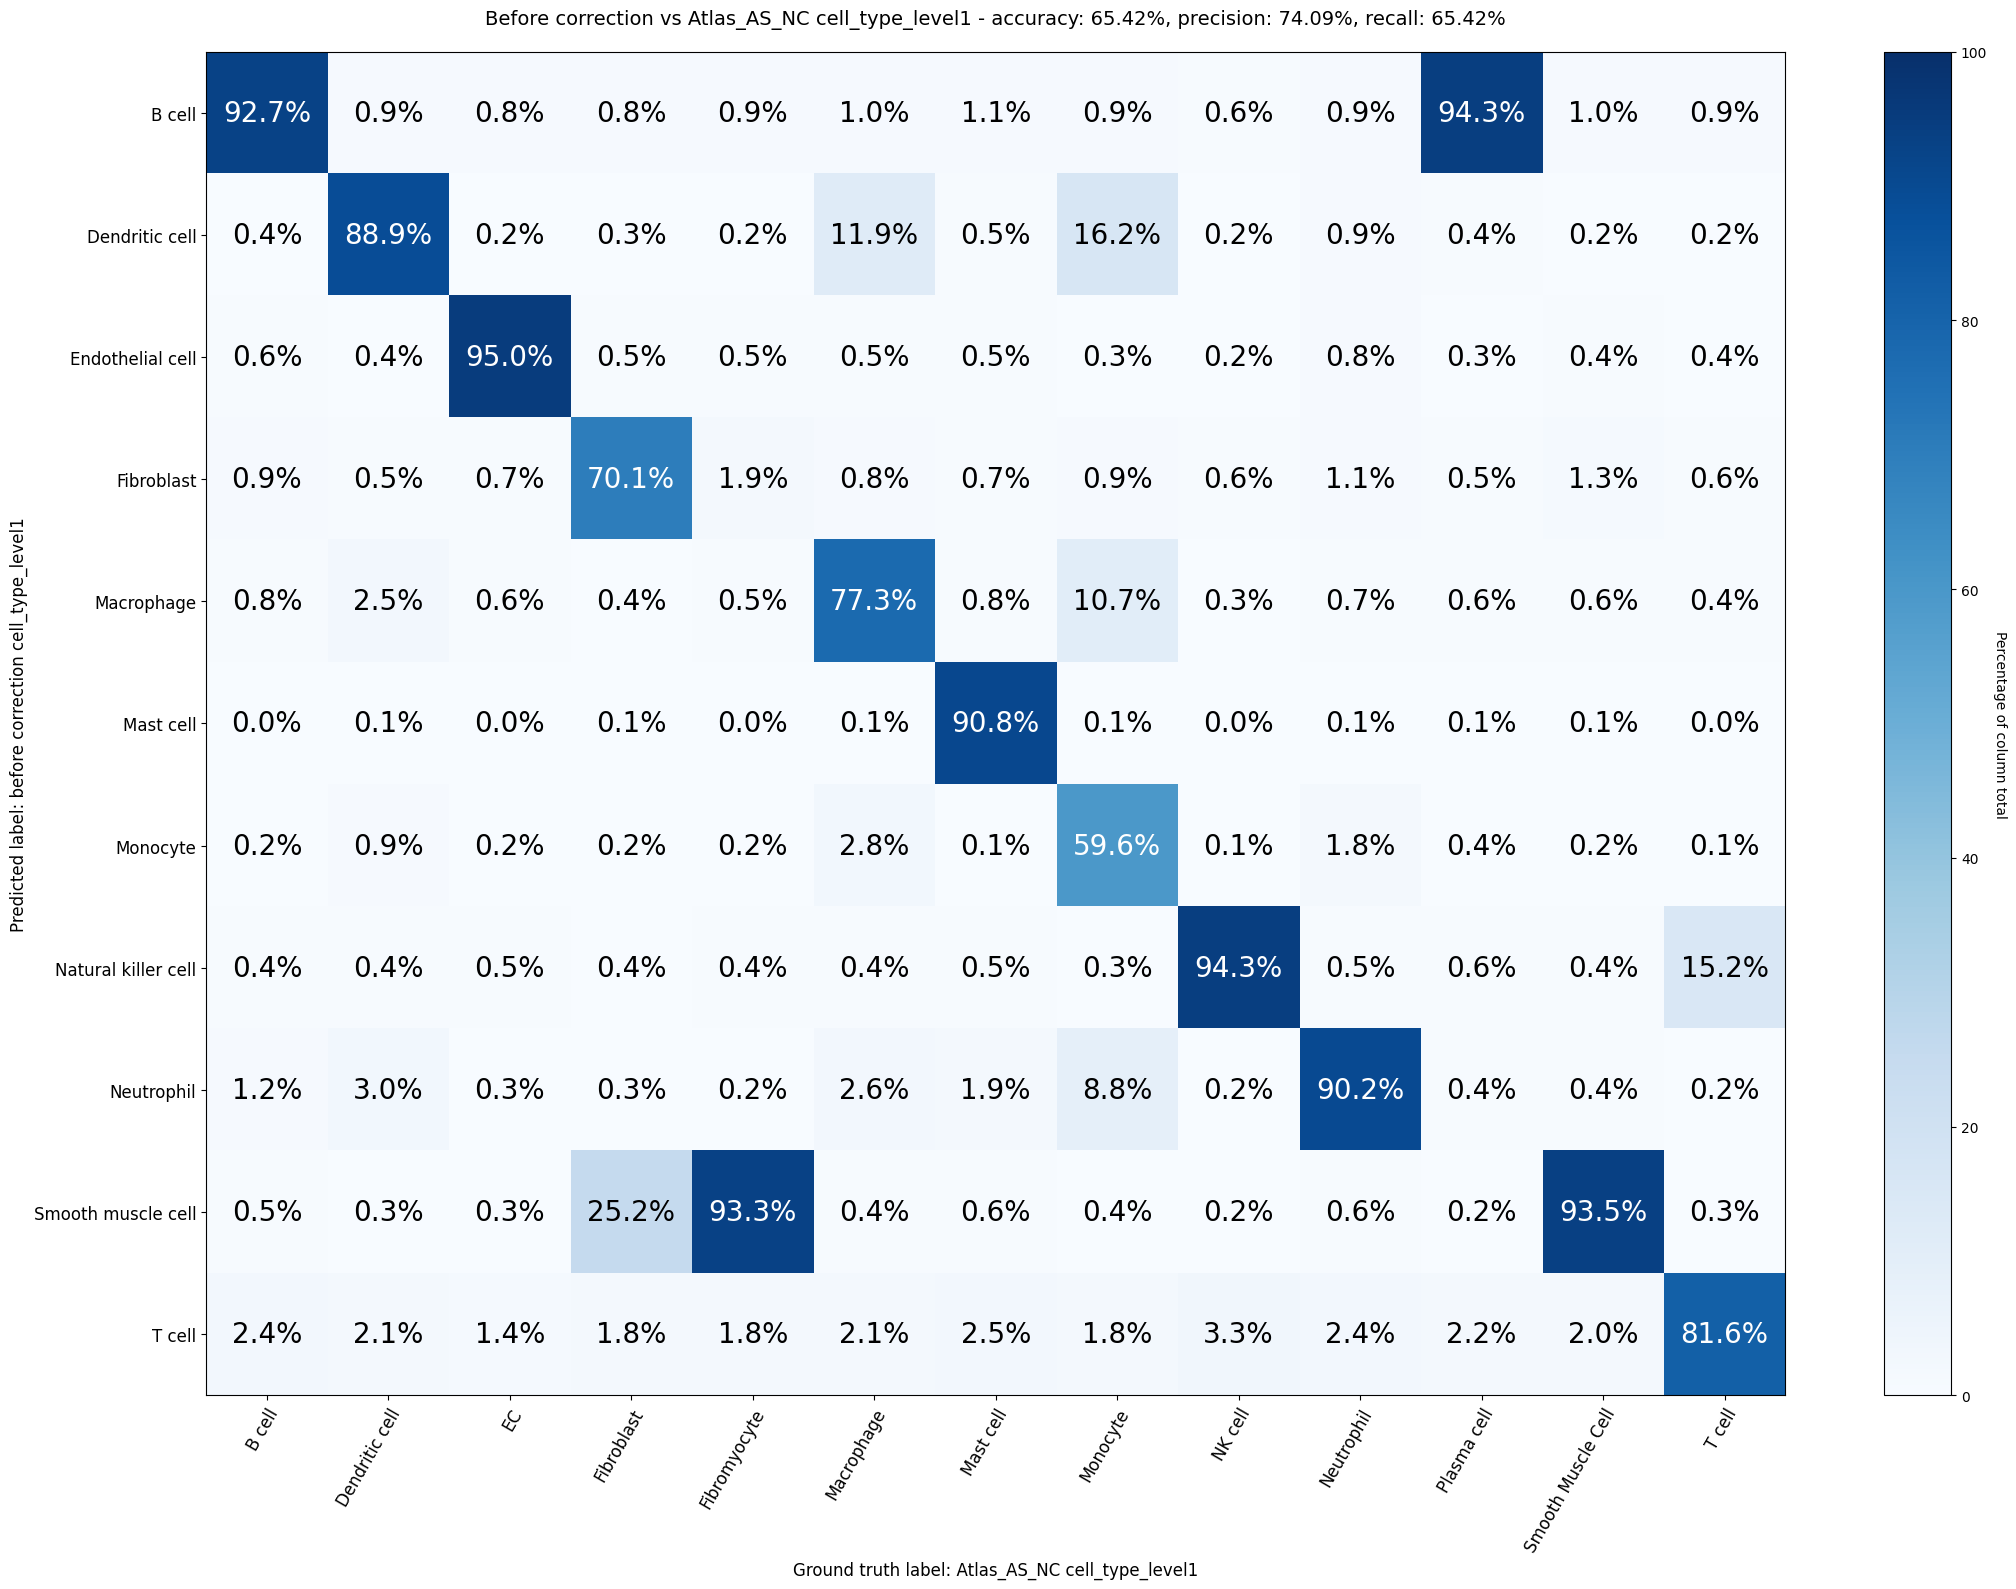


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.698687
1        Dendritic cell   0.489740
2      Endothelial cell   0.000000
3            Fibroblast   0.793011
4            Macrophage   0.923008
5             Mast cell   0.949030
6              Monocyte   0.822192
7   Natural killer cell   0.000000
8            Neutrophil   0.592249
9    Smooth muscle cell   0.000000
10               T cell   0.973452

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.926856
1       Dendritic cell  0.889253
2                   EC  0.000000
3           Fibroblast  0.701239
4         Fibromyocyte  0.000000
5           Macrophage  0.773457
6            Mast cell  0.908071
7             Monocyte  0.595854
8              NK cell  0.000000
9           Neutrophil  0.901912
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.815722


In [ ]:
###校正前
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2/scPoli_concat_level2_marker_all.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


当前 AnnData 中共有 548208 个细胞
去除指定细胞类型后共有 529042 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 190893 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.6525
Weighted precision: 0.7411
Weighted recall: 0.6525

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


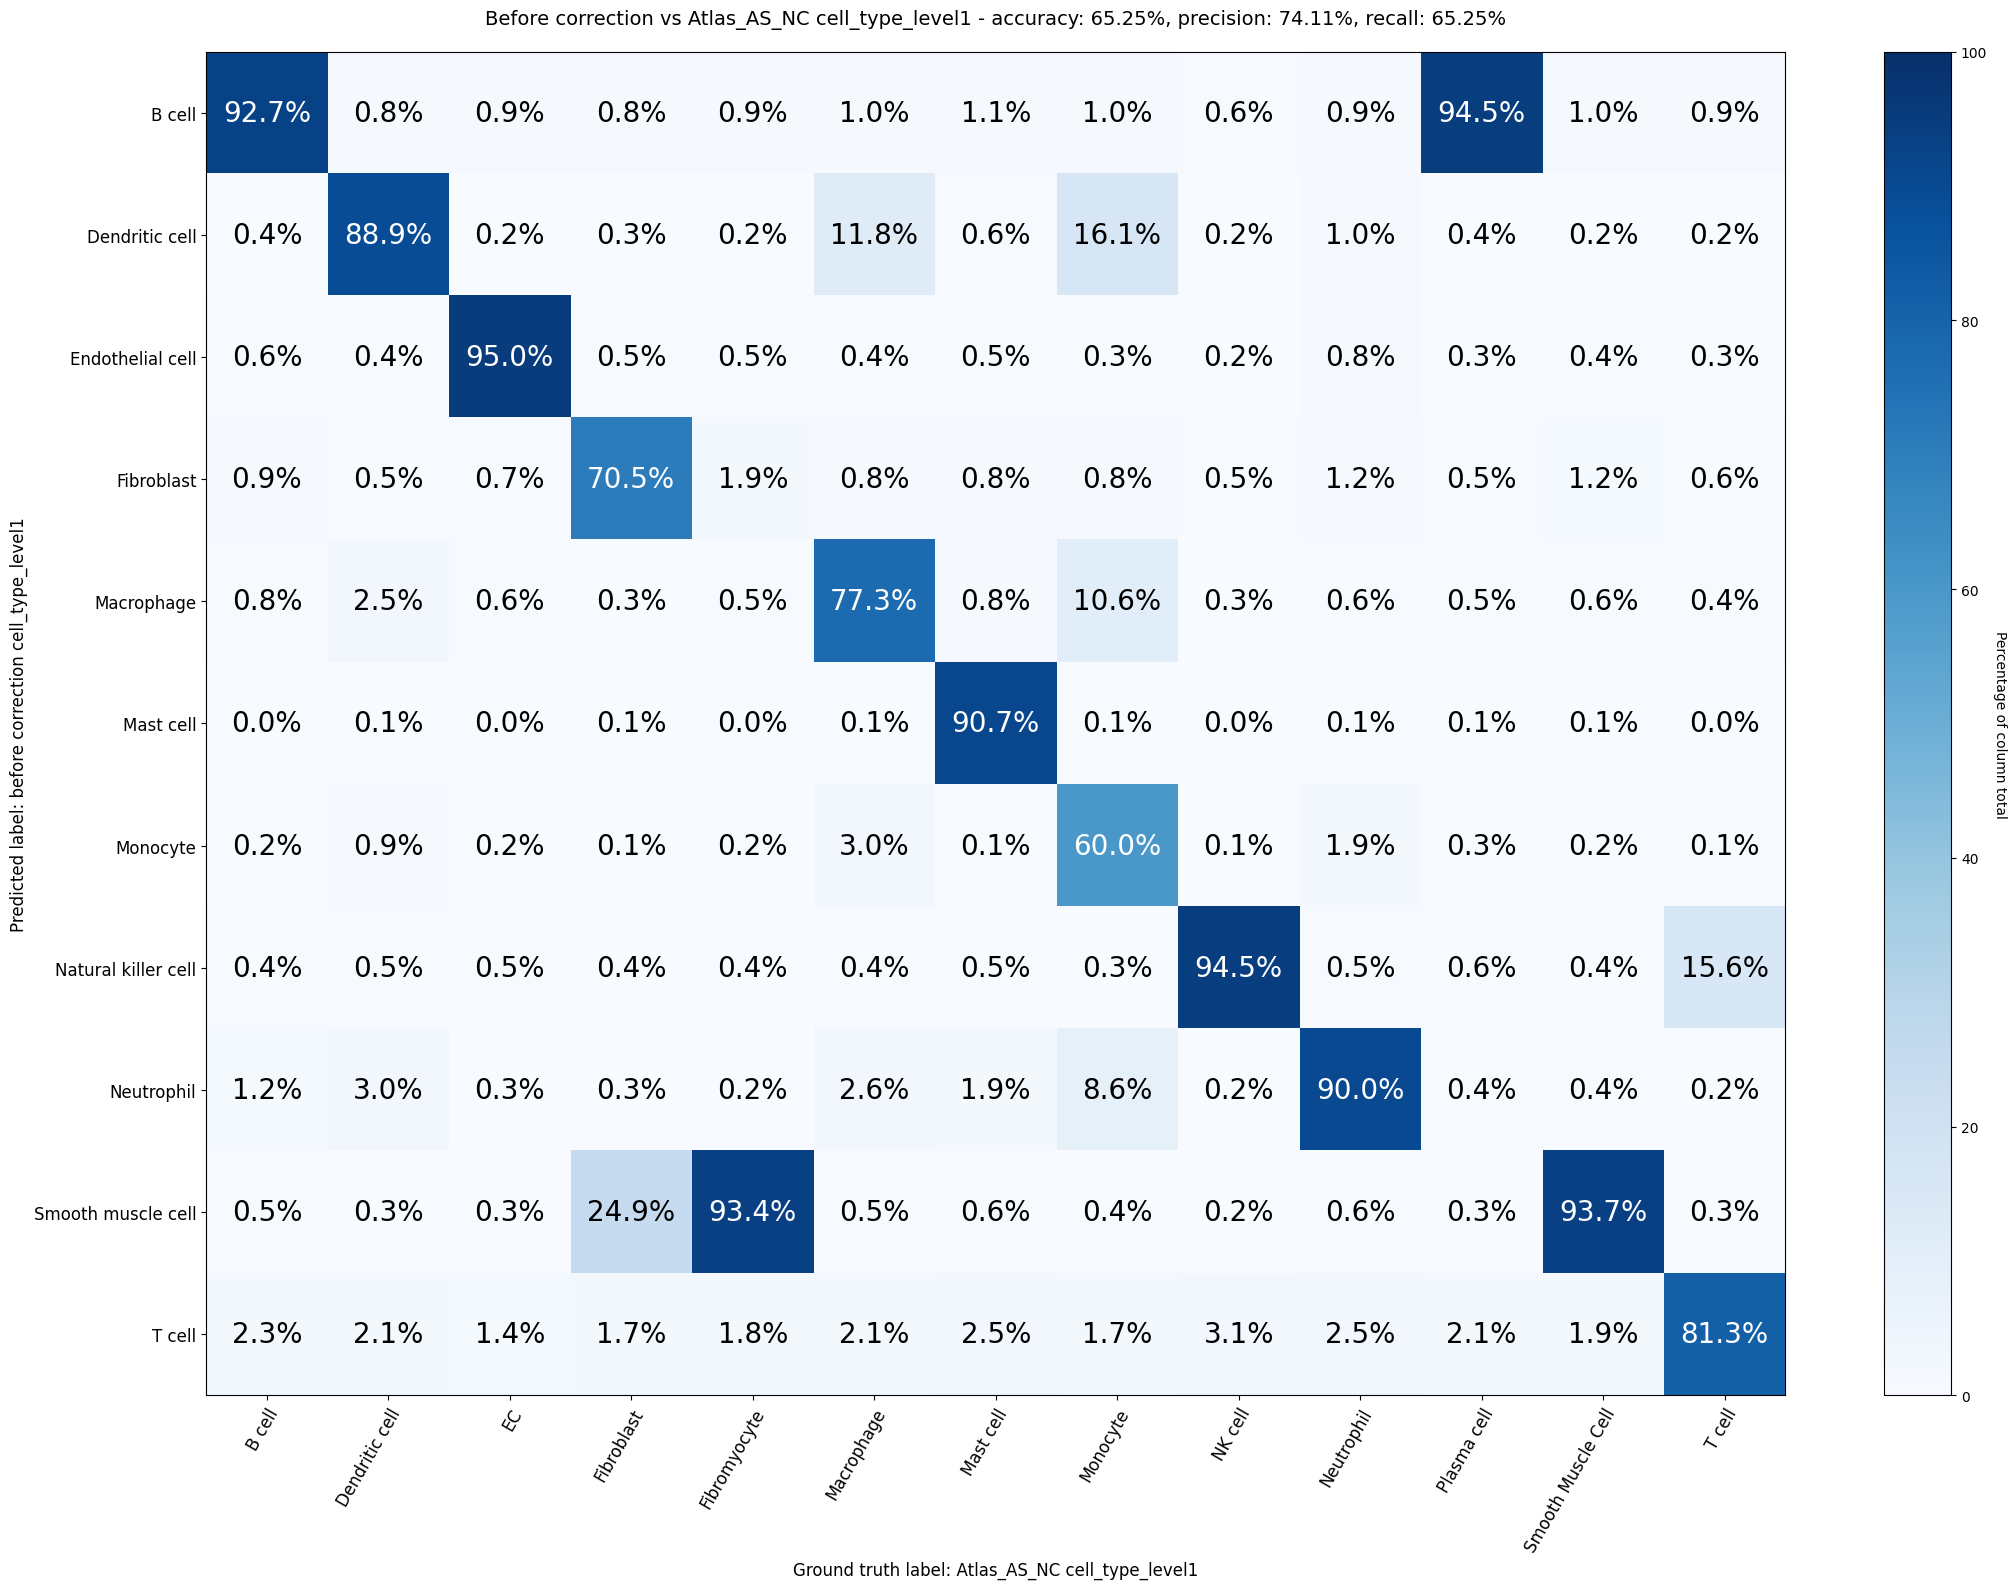


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.693848
1        Dendritic cell   0.494047
2      Endothelial cell   0.000000
3            Fibroblast   0.800030
4            Macrophage   0.922544
5             Mast cell   0.947652
6              Monocyte   0.818527
7   Natural killer cell   0.000000
8            Neutrophil   0.587604
9    Smooth muscle cell   0.000000
10               T cell   0.974329

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.927384
1       Dendritic cell  0.889357
2                   EC  0.000000
3           Fibroblast  0.705485
4         Fibromyocyte  0.000000
5           Macrophage  0.772868
6            Mast cell  0.906835
7             Monocyte  0.600417
8              NK cell  0.000000
9           Neutrophil  0.899635
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.812570


In [22]:
#
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="../../7_mapping_new_data/0511_rename_noIAISR/output_human/Atlas_allhuman_with_measure_allgeneID-inner-counts-annot.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

cell_type_level1
T cell                   183446
B cell                    56046
Macrophage                55696
Natural killer cell       51294
Fibroblast                49419
Smooth muscle cell        42831
Endothelial cell          30615
Dendritic cell            24663
Monocyte                  16448
Neutrophil                14157
Pericyte                   9864
Basophil                   6162
Mast cell                  4427
Erythrocyte/Erythroid      3140
Name: count, dtype: int64
当前 AnnData 中共有 548208 个细胞
去除指定细胞类型后共有 529042 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 203274 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth musc

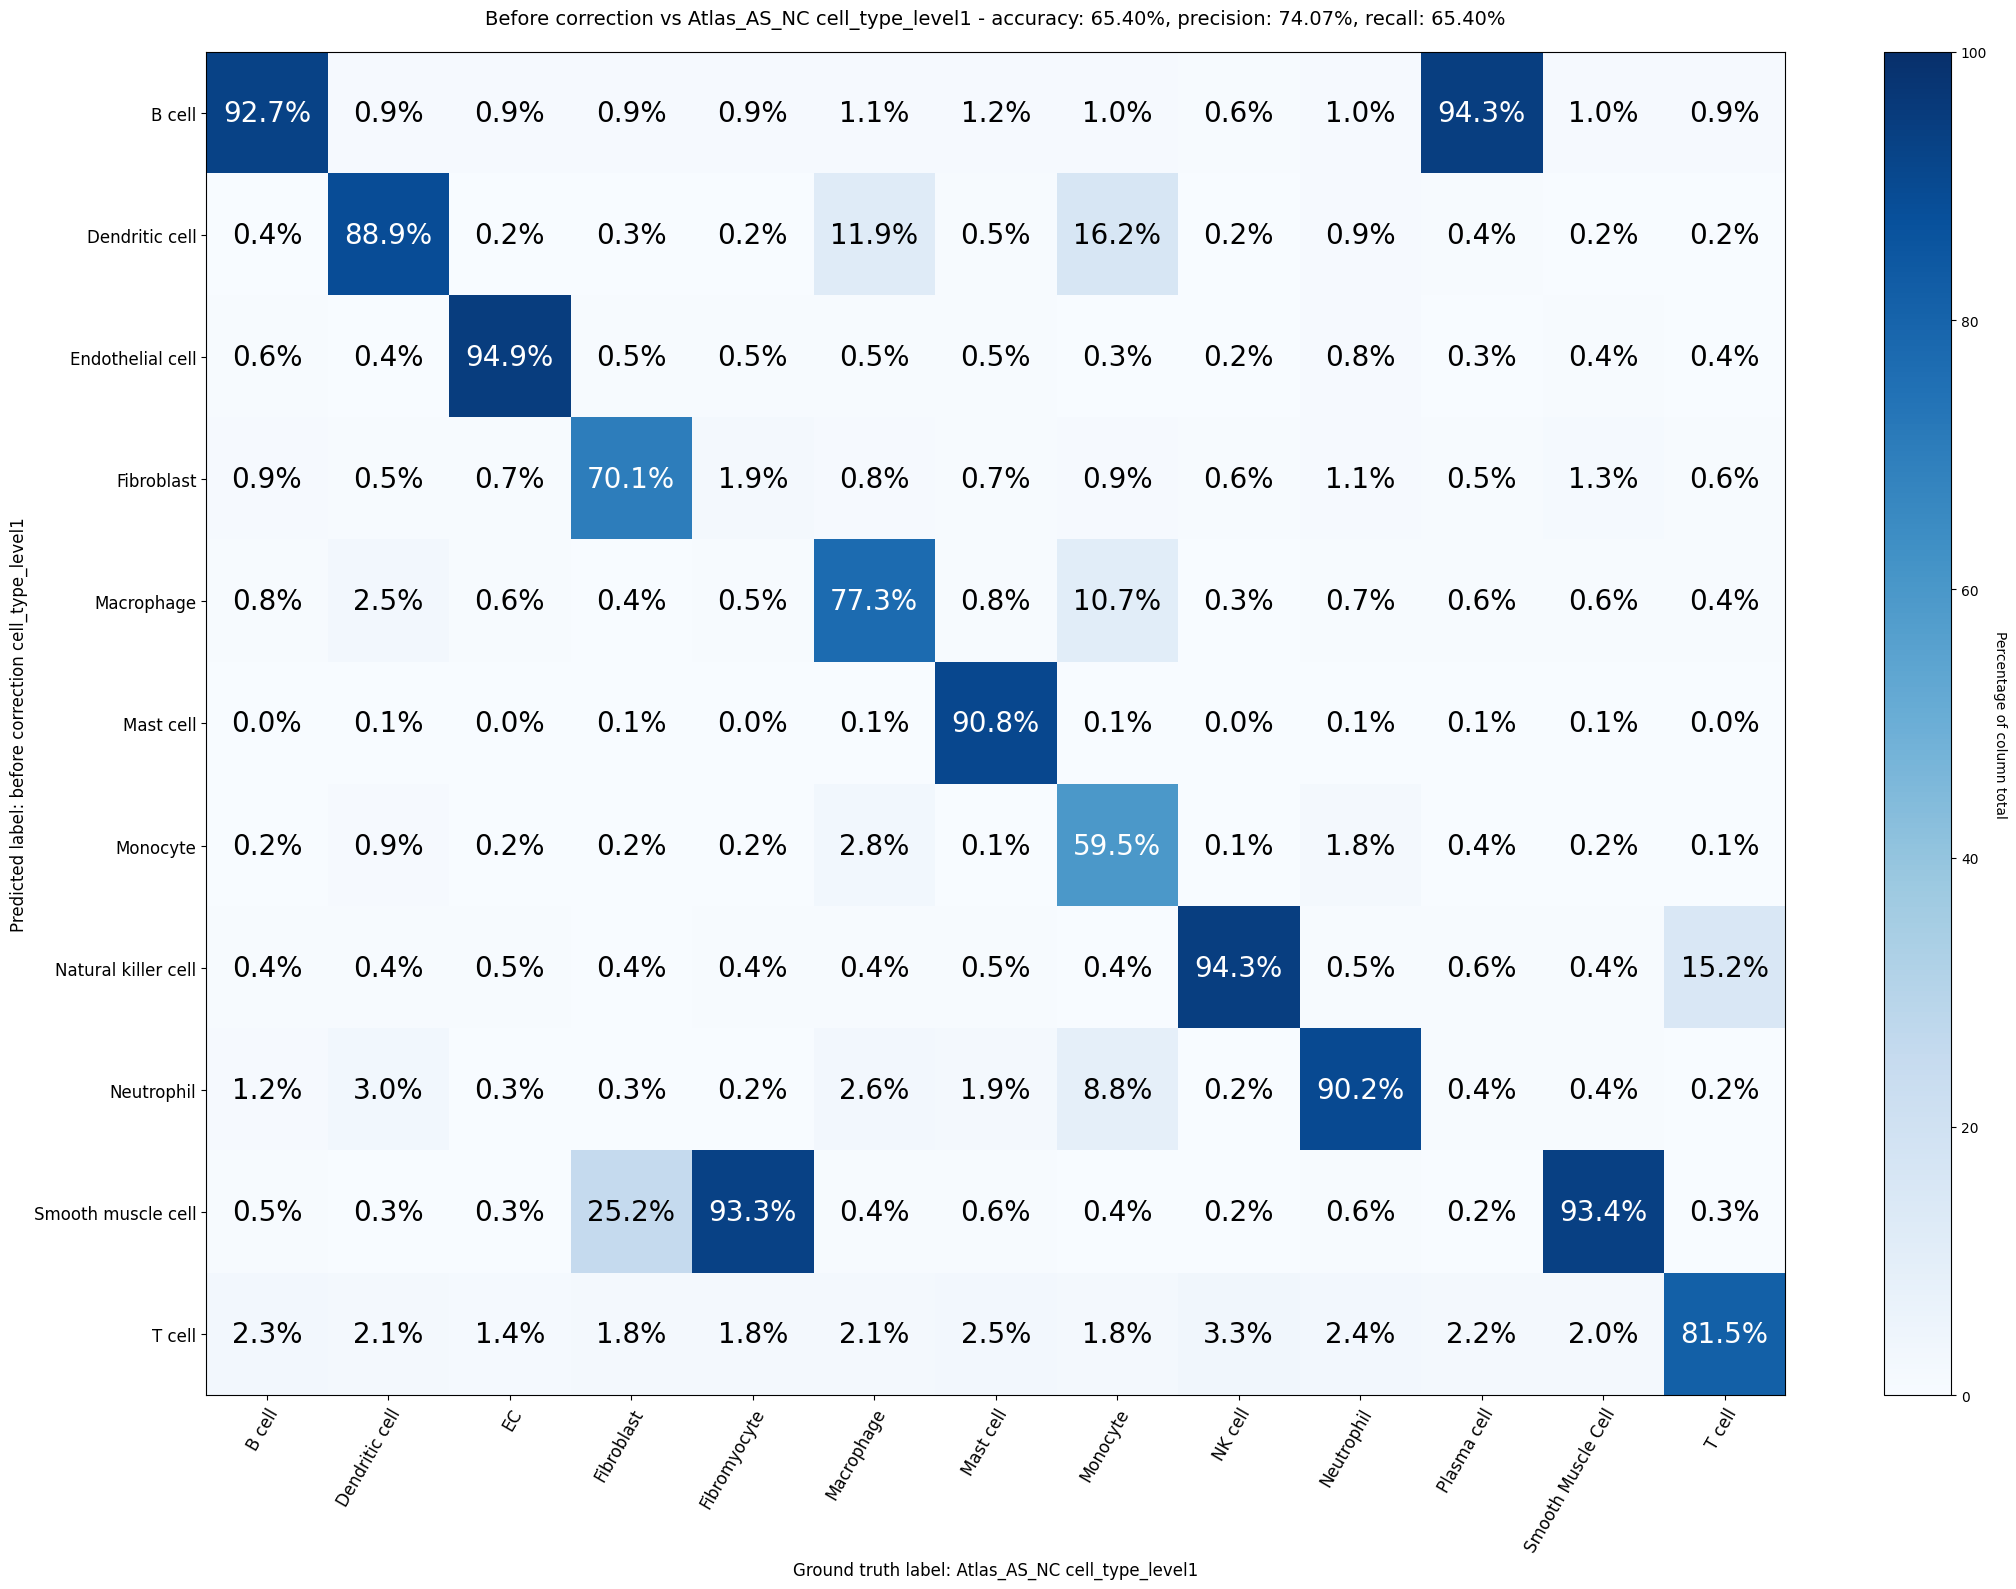


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.693640
1        Dendritic cell   0.489740
2      Endothelial cell   0.000000
3            Fibroblast   0.793011
4            Macrophage   0.923008
5             Mast cell   0.949030
6              Monocyte   0.822192
7   Natural killer cell   0.000000
8            Neutrophil   0.592249
9    Smooth muscle cell   0.000000
10               T cell   0.973452

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.926987
1       Dendritic cell  0.888640
2                   EC  0.000000
3           Fibroblast  0.700975
4         Fibromyocyte  0.000000
5           Macrophage  0.772667
6            Mast cell  0.907679
7             Monocyte  0.595399
8              NK cell  0.000000
9           Neutrophil  0.901662
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.815476


In [19]:
# corrected 2.0 校正前：省内存 + 加速版----因为校正是dc没改名的校正--所以这里的数据得是dc没改名字的数据 7.5开头的文件
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors

# path_bef="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/0507_no_IAISR/output_human/mergerd_aggred-log-normalized-allgene-counts-no_IAISR_2_rename.h5ad"
path_bef='/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/0511_rename_noIAISR/output_human/mergerd_aggred-log-normalized-allgene-no_IAISR_2_rename.h5ad'
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]

adata_bef_correct.obs_names_make_unique()
adata_ref.obs_names_make_unique()
print(adata_bef_correct.obs['cell_type_level1'].value_counts())
n_obs_before=adata_bef_correct.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_bef_correct.obs[["cell_type_level1"]].copy()
obs_before.index=adata_bef_correct.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_bef_correct.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(
#     "annotation_confusion_matrix_before_correction_vs_Atlas_AS_NC_cell_type_level1.png",
#     dpi=200
# )

plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

In [11]:
adata_bef_correct.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   183373
B cell                    56064
Macrophage                55746
Natural killer cell       51315
Fibroblast                49454
Smooth muscle cell        42810
Endothelial cell          30622
Dendritic cell            24557
Monocyte                  16465
Neutrophil                14211
Pericyte                   9868
Basophil                   6172
Mast cell                  4427
Erythrocyte/Erythroid      3124
Name: count, dtype: int64

In [13]:
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   183446
B cell                    56046
Macrophage                55696
Natural killer cell       51294
Fibroblast                49419
Smooth muscle cell        42831
Endothelial cell          30615
Dendritic cell            24663
Monocyte                  16448
Neutrophil                14157
Pericyte                   9864
Basophil                   6162
Mast cell                  4427
Erythrocyte/Erythroid      3140
Name: count, dtype: int64